In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def hex_file_to_image_list(filepath, width=28, height=28, rowmajor=True):
    """
    Read a text file containing one hex value per line and convert it
    into a 2D Python list of shape (height, width).

    Parameters:
    - rowmajor=True  -> interpret values in row-major order
    - rowmajor=False -> interpret values in column-major order
    """
    with open(filepath, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    expected = width * height
    if len(lines) != expected:
        raise ValueError(f"Expected {expected} lines, got {len(lines)}")

    try:
        values = [int(x, 16) for x in lines]
    except ValueError as e:
        raise ValueError(f"Invalid hexadecimal value: {e}")

    # initialize empty grid
    image = [[0 for _ in range(width)] for _ in range(height)]

    if rowmajor:
        # fill row by row
        idx = 0
        for r in range(height):
            for c in range(width):
                image[r][c] = values[idx]
                idx += 1
    else:
        # fill column by column
        idx = 0
        for c in range(width):
            for r in range(height):
                image[r][c] = values[idx]
                idx += 1

    return image

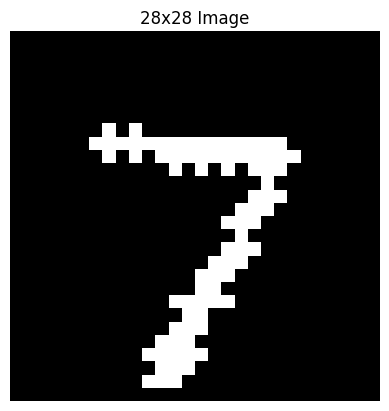

In [14]:
filepath = "testImage_7.mem"   # replace with your actual file path
img_list = hex_file_to_image_list(filepath, rowmajor=False)

plt.imshow(img_list, cmap="gray", vmin=0, vmax=255)
plt.title("28x28 Image")
plt.axis("off")
plt.show()

In [19]:
# input / output paths
input_path = "testImage_7.mem"
output_path = "testImage_7_b.mem"

width = 28
height = 28

# --- read file ---
with open(input_path, "r") as f:
    lines = [line.strip() for line in f if line.strip()]

if len(lines) != width * height:
    raise ValueError(f"Expected {width*height} values, got {len(lines)}")

values = [int(x, 16) for x in lines]

# --- reconstruct grid from column-major ---
grid = [[0 for _ in range(width)] for _ in range(height)]

idx = 0
for c in range(width):
    for r in range(height):
        grid[r][c] = values[idx]
        idx += 1

# --- flatten back to row-major + remap values ---
output_values = []

for r in range(height):
    for c in range(width):
        val = grid[r][c]

        # remap values
        if val == 0x00:
            new_val = "00"
        elif val == 0xFF:
            new_val = "01"
        else:
            # keep other values as 2-digit hex
            new_val = format(val, "02X")

        output_values.append(new_val)

# --- write output file ---
with open(output_path, "w") as f:
    for v in output_values:
        f.write(v + "\n")

print("Done. Wrote:", output_path)

Done. Wrote: testImage_7_b.mem


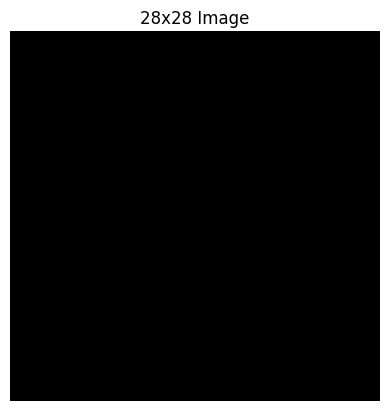

In [20]:
filepath = "testImage_7_b.mem"   # replace with your actual file path
img_list = hex_file_to_image_list(filepath, rowmajor=True)

plt.imshow(img_list, cmap="gray", vmin=0, vmax=255)
plt.title("28x28 Image")
plt.axis("off")
plt.show()